# Practical No. 01 — Artificial Neural Network (ANN) using TensorFlow/Keras

### Subject: Advanced Data Science Laboratory (PEIT412B) CO1: Implement deep learning models using TensorFlow/PyTorch frameworks.

### Problem Statement: Student Performance Prediction (Regression)
### Predict a student's exam score/marks using features such as study hours, attendance, sleep, and past scores.

### Dataset used: student_exam_scores.csv (Kaggle — Student Exam Scores dataset) Place the CSV file in the same folder as this notebook before running.


In [1]:
# Practical No. 01 — Artificial Neural Network (ANN) using TensorFlow/Keras
# Dataset: UCI Student Performance Data Set (student-mat.csv / student-por.csv)
# Source : https://www.kaggle.com/datasets/larsen0966/student-performance-data-set
#
# Place student-mat.csv (and/or student-por.csv) in the same folder as this script.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

np.random.seed(42)

In [4]:
# ----------------------------------------------------------------------
# CONFIG — edit these two lines to match what you want to run
# ----------------------------------------------------------------------
DATA_FILE = "C:/Users/bhagyashree/OneDrive/Desktop/ADS_Assignments_Lab/Assignment 01/student-por.csv"
DROP_G1_G2 = True               # True = harder/more realistic task (predict G3 from
                                 #        background/behavior only, not earlier grades)
                                 # False = also use G1, G2 as predictors (easier, less realistic)

# 1. Data Ingestion
# NOTE: this dataset uses ';' as the delimiter, not ','
df = pd.read_csv(DATA_FILE, sep=',')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.head()

Shape: (649, 33)

Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [5]:
# 2. Data Cleaning
df = df.dropna()

TARGET_COLUMN = 'G3'  # final grade (0-20)

if DROP_G1_G2:
    df = df.drop(columns=['G1', 'G2'])

In [6]:
# 3. Encode categorical features
# This dataset mixes yes/no binary columns, ordinal-ish numeric columns (Medu, Fedu,
# famrel, Dalc, Walc, etc. are already numeric 0-5 scales) and a handful of true
# multi-category string columns (Mjob, Fjob, reason, guardian).
binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
               'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
               'higher', 'internet', 'romantic']
multi_cat_cols = ['Mjob', 'Fjob', 'reason', 'guardian']

# Label-encode binary yes/no-style columns (2 categories -> 0/1)
le = LabelEncoder()
for col in binary_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

# One-hot encode true multi-category columns
df = pd.get_dummies(df, columns=[c for c in multi_cat_cols if c in df.columns], drop_first=True)

# Check class balance on a couple of known-imbalanced columns
for col in ['higher', 'internet', 'famsize']:
    if col in df.columns:
        print(f"\nValue counts for '{col}':")
        print(df[col].value_counts())

X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

print("\nFinal feature count:", X.shape[1])
print("Target:", TARGET_COLUMN, "| Dropped G1/G2:", DROP_G1_G2)


Value counts for 'higher':
higher
1    580
0     69
Name: count, dtype: int64

Value counts for 'internet':
internet
1    498
0    151
Name: count, dtype: int64

Value counts for 'famsize':
famsize
0    457
1    192
Name: count, dtype: int64

Final feature count: 39
Target: G3 | Dropped G1/G2: True


In [7]:
# 4. Train-Test Split & Feature Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# 5. Build the ANN (Keras Sequential API)
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')   # linear output for regression
])

model.summary()

C:\Users\bhagyashree\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           2,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,185 (20.25 KB)

 Trainable params: 5,185 (20.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 6. Compile the Model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 7. Train the Model
history = model.fit(
    X_train_scaled, y_train,
    epochs=100, batch_size=16,
    validation_split=0.2, verbose=1
)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 146.5336 - mae: 11.6485 - val_loss: 123.8131 - val_mae: 10.8023
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 111.4342 - mae: 9.9980 - val_loss: 67.1494 - val_mae: 7.7276
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 50.0018 - mae: 6.3039 - val_loss: 12.2515 - val_mae: 2.8026
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 13.9128 - mae: 2.8902 - val_loss: 8.0458 - val_mae: 2.2352
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 8.6671 - mae: 2.2766 - val_loss: 7.6448 - val_mae: 2.1450
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 8.3222 - mae: 2.1763 - val_loss: 7.3885 - val_mae: 2.0896
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 7.5146 - mae: 2.0339 - val_loss: 7.3428 - val_mae: 2.0658
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 7.3469 - mae: 2.0086 - val_loss: 7.3494 - val_mae: 2.0520
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3193 - mae: 0.3956 - val_loss: 7.6350 - val_mae: 2.1578
Epoch 55/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2789 - mae: 0.3712 - val_loss: 7.6365 - val_mae: 2.1607
Epoch 56/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.2685 - mae: 0.3658 - val_loss: 7.6274 - val_mae: 2.1621
Epoch 57/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.2548 - mae: 0.3560 - val_loss: 7.6235 - val_mae: 2.1460
Epoch 58/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.2734 - mae: 0.3451 - val_loss: 7.6388 - val_mae: 2.1624
Epoch 59/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1828 - mae: 0.2970 - val_loss: 7.7029 - val_mae: 2.1701
Epoch 60/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1493 - mae: 0.2701 - val_loss: 7.6372 - val_mae: 2.1582
Epoch 61/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1793 - mae: 0.2943 - val_loss: 7.5301 - val_mae: 2.1366
Epoch 62/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 

In [10]:
# 8. Evaluate the Model
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
y_pred = model.predict(X_test_scaled, verbose=0)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTest Loss (MSE): {loss:.3f}")
print(f"Test MAE       : {mae:.3f}")
print(f"Test RMSE      : {rmse:.3f}")


Test Loss (MSE): 9.806
Test MAE       : 2.445
Test RMSE      : 3.131


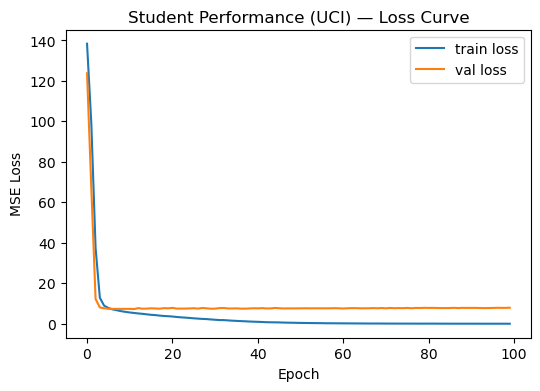

In [11]:
# 9. Visualize Training Curves
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Student Performance (UCI) — Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [12]:
# 10. Sample Predictions
results = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10].flatten()
})
print(results)

   Actual  Predicted
0      19  16.611950
1      12  11.196250
2      18  17.571829
3      11  14.754106
4      11  15.431564
5      17  14.910854
6      18  16.618870
7       8   7.695608
8      10  12.806984
9      11  13.131648
